# Reto |  Segmentación de datos de empleados 


## importaciones

In [71]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import numpy as np
from sklearn import metrics
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt
from matplotlib import cm as cm
from sklearn.decomposition import PCA
import plotly.graph_objects as go

## # ----------------------- 2. Carga los datos del archivo.

In [72]:
empleados = pd.read_csv("Train.csv")

# a continuacion se realizaran algunas pruebas para poder conocer la forma del df general, y ademas de tipos de datos y ver si se necesitan cambios adicionales

In [73]:
empleados.shape

(7000, 24)

In [74]:
empleados.dtypes

Employee_ID                   object
Gender                        object
Age                          float64
Education_Level                int64
Relationship_Status           object
Hometown                      object
Unit                          object
Decision_skill_possess        object
Time_of_service              float64
Time_since_promotion           int64
growth_rate                    int64
Travel_Rate                    int64
Post_Level                     int64
Pay_Scale                    float64
Compensation_and_Benefits     object
Work_Life_balance            float64
VAR1                           int64
VAR2                         float64
VAR3                         float64
VAR4                         float64
VAR5                           int64
VAR6                           int64
VAR7                           int64
Attrition_rate               float64
dtype: object

In [75]:
empleados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Employee_ID                7000 non-null   object 
 1   Gender                     7000 non-null   object 
 2   Age                        6588 non-null   float64
 3   Education_Level            7000 non-null   int64  
 4   Relationship_Status        7000 non-null   object 
 5   Hometown                   7000 non-null   object 
 6   Unit                       7000 non-null   object 
 7   Decision_skill_possess     7000 non-null   object 
 8   Time_of_service            6856 non-null   float64
 9   Time_since_promotion       7000 non-null   int64  
 10  growth_rate                7000 non-null   int64  
 11  Travel_Rate                7000 non-null   int64  
 12  Post_Level                 7000 non-null   int64  
 13  Pay_Scale                  6991 non-null   float

In [76]:
"""para visualizar los nombres de cada columna de manera individual"""
empleados.columns

Index(['Employee_ID', 'Gender', 'Age', 'Education_Level',
       'Relationship_Status', 'Hometown', 'Unit', 'Decision_skill_possess',
       'Time_of_service', 'Time_since_promotion', 'growth_rate', 'Travel_Rate',
       'Post_Level', 'Pay_Scale', 'Compensation_and_Benefits',
       'Work_Life_balance', 'VAR1', 'VAR2', 'VAR3', 'VAR4', 'VAR5', 'VAR6',
       'VAR7', 'Attrition_rate'],
      dtype='object')

In [77]:
"""aqui se identificaron mayusculas en todos los nombres de columnas, entonces lo limpio para seguir"""
empleados.columns = empleados.columns.str.lower()
empleados.columns

Index(['employee_id', 'gender', 'age', 'education_level',
       'relationship_status', 'hometown', 'unit', 'decision_skill_possess',
       'time_of_service', 'time_since_promotion', 'growth_rate', 'travel_rate',
       'post_level', 'pay_scale', 'compensation_and_benefits',
       'work_life_balance', 'var1', 'var2', 'var3', 'var4', 'var5', 'var6',
       'var7', 'attrition_rate'],
      dtype='object')

In [78]:
empleados.sample(10)
#verifico la integridad general de 10 muestras

,employee_id,gender,age,education_level,relationship_status,hometown,unit,decision_skill_possess,time_of_service,time_since_promotion,...,compensation_and_benefits,work_life_balance,var1,var2,var3,var4,var5,var6,var7,attrition_rate
5923,EID_23971,F,27.0,5,Married,Franklin,Marketing,Analytical,3.0,2,...,type3,4.0,3,0.7516,-0.4537,NaN,2,7,5,0.1784
713,EID_1224,M,60.0,3,Single,Lebanon,R&D,Directive,31.0,1,...,type2,4.0,3,-0.1048,0.7075,2.0,1,6,3,0.0134
167,EID_15313,M,24.0,1,Single,Franklin,Operarions,Conceptual,5.0,2,...,type3,3.0,1,-0.1048,-0.4537,2.0,4,9,4,0.4052
5939,EID_12211,F,30.0,5,Single,Springfield,IT,Conceptual,7.0,4,...,type1,3.0,4,-0.9612,-0.4537,2.0,1,8,3,0.4036
4159,EID_17893,F,22.0,5,Single,Franklin,Operarions,Conceptual,3.0,2,...,type2,3.0,5,-0.1048,-0.4537,NaN,3,6,4,0.1806
4651,EID_3282,F,55.0,3,Married,Springfield,Logistics,Directive,32.0,4,...,type4,3.0,3,1.6081,0.7075,2.0,4,8,3,0.1004
2746,EID_7174,F,42.0,3,Single,Franklin,Sales,Analytical,8.0,4,...,type2,4.0,4,-1.8176,0.7075,2.0,4,9,3,0.1425
4902,EID_1152,F,60.0,3,Married,Springfield,Marketing,Conceptual,31.0,2,...,type3,3.0,2,0.7516,1.8688,2.0,4,8,3,0.2627
992,EID_11427,F,33.0,3,Married,Springfield,IT,Behavioral,4.0,1,...,type2,2.0,3,-0.9612,1.8688,2.0,3,7,1,0.1656
4402,EID_12077,M,35.0,5,Single,Lebanon,Sales,Behavioral,10.0,4,...,type3,1.0,3,0.7516,-2.7762,1.0,2,6,2,0.0367


## # ----------------------- 3. Transforma los datos según las características de las variables:


In [79]:
"""para el caso de (employee_id), se sabe que es un elemento primario, que sirve de identificador y es unico por empleado lo cual no nos sirve para los grupos. los elimino"""

empleados = empleados.drop(columns=["employee_id"])
empleados.sample(10)

,gender,age,education_level,relationship_status,hometown,unit,decision_skill_possess,time_of_service,time_since_promotion,growth_rate,...,compensation_and_benefits,work_life_balance,var1,var2,var3,var4,var5,var6,var7,attrition_rate
6314,M,46.0,2,Married,Springfield,IT,Directive,10.0,1,36,...,type2,1.0,3,1.6081,0.7075,NaN,3,7,4,0.1021
3057,F,63.0,1,Married,Clinton,Operarions,Conceptual,37.0,3,37,...,type3,4.0,4,-1.8176,0.7075,1.0,3,9,4,0.0341
5815,M,27.0,3,Married,Springfield,IT,Analytical,4.0,1,54,...,type2,5.0,1,-0.1048,-1.6150,2.0,2,8,4,0.1265
5318,M,54.0,2,Married,Springfield,Operarions,Conceptual,30.0,1,57,...,type2,2.0,3,-0.9612,-0.4537,2.0,3,8,3,0.2885
4777,F,27.0,1,Married,Washington,IT,Directive,3.0,1,39,...,type3,1.0,3,-0.1048,1.8688,2.0,2,5,3,0.2652
159,M,63.0,3,Married,Springfield,Logistics,Conceptual,37.0,2,39,...,type2,1.0,4,-0.1048,-0.4537,NaN,2,8,4,0.0482
2071,F,45.0,3,Married,Springfield,Production,Directive,17.0,2,25,...,type2,3.0,3,0.7516,-0.4537,2.0,3,5,4,0.0427
4808,F,21.0,4,Married,Springfield,Accounting and Finance,Analytical,2.0,2,37,...,type3,1.0,1,-1.8176,-0.4537,2.0,2,7,4,0.2524
243,F,37.0,3,Married,Franklin,Accounting and Finance,Analytical,15.0,4,44,...,type2,1.0,3,-1.8176,-0.4537,2.0,4,8,3,0.1908
3618,M,25.0,3,Married,Franklin,Sales,Directive,6.0,3,71,...,type3,2.0,3,-0.9612,0.7075,2.0,2,8,2,0.1039


### las siguientes columnas fueron las encontradas con NaN's
- age
- time_of_service
- work_life_balance
- var2
- var4
para estas columnas opto por usar el por usar el promedio general de cada columna para rellenar los espacios faltantes para no borrar las filas y no perder informacion o poner ceros deliberadamente, lo cual tiene un efecto de sesgo. es util por los tipos de datos numericos que hay en las demas filas. Se deja el dtype de cada una de las columnas

In [80]:
empleados = empleados.fillna(empleados.mean(numeric_only=True))
#verificacion de que ya no hay NaN
empleados.isna().sum()

gender                       0
age                          0
education_level              0
relationship_status          0
hometown                     0
unit                         0
decision_skill_possess       0
time_of_service              0
time_since_promotion         0
growth_rate                  0
travel_rate                  0
post_level                   0
pay_scale                    0
compensation_and_benefits    0
work_life_balance            0
var1                         0
var2                         0
var3                         0
var4                         0
var5                         0
var6                         0
var7                         0
attrition_rate               0
dtype: int64

## ----------------------- 3.a Puede usar diferentes métodos de transformación, como OrdinalEncoder, OneHotEncoder, StandardEncoder, NormalizerEncoder, etc.

In [81]:
"""aca se realiza una separacion, de todas las columnas que son numericas o categoricas"""

#categoricas
columnas_categoricas = empleados.select_dtypes(exclude="number").columns.tolist()
print(columnas_categoricas)
"""hay 6 variables categoricas, aqui la clave es usar onehotencoder"""

onehot = OneHotEncoder(sparse_output=False)
categoricas_codificadas = onehot.fit_transform(empleados[columnas_categoricas])
nombres_onehot = onehot.get_feature_names_out(columnas_categoricas)

empleados_categoricas = pd.DataFrame(categoricas_codificadas, columns=nombres_onehot, index=empleados.index)

['gender', 'relationship_status', 'hometown', 'unit', 'decision_skill_possess', 'compensation_and_benefits']


In [82]:
#numericas
columnas_numericas = empleados.select_dtypes(include="number").columns.tolist()
print(columnas_numericas)

scaler = StandardScaler()
numericas_escaladas = scaler.fit_transform(empleados[columnas_numericas])

empleados_numericas = pd.DataFrame(
    numericas_escaladas, columns=columnas_numericas, index=empleados.index
)

['age', 'education_level', 'time_of_service', 'time_since_promotion', 'growth_rate', 'travel_rate', 'post_level', 'pay_scale', 'work_life_balance', 'var1', 'var2', 'var3', 'var4', 'var5', 'var6', 'var7', 'attrition_rate']


In [83]:
"""agrupo las variables escaladas y las codigicadas"""

x_df = pd.concat([empleados_numericas, empleados_categoricas], axis=1)
x = x_df.to_numpy()
x.shape

(7000, 47)

## ----------------------- 4. Selecciona el número de grupos adecuados para agrupar usando K-means:
### ----------------------- 4.a Ejecuta el algoritmo K-means con distintos números de grupos y almacena los resultados.


In [84]:
np.random.seed(0)

#diccionarios vacios para tener donde se guardara el agrupamiento
resultados_silhouette = {}
resultados_calinski = {}

for k in range(2, 11):
    y_pred = KMeans(n_clusters=k, n_init=10).fit_predict(x)
    resultados_silhouette[k] = metrics.silhouette_score(x, y_pred)
    resultados_calinski[k] = metrics.calinski_harabasz_score(x, y_pred)

print(resultados_silhouette)
print(resultados_calinski)

{2: 0.06919703322608427, 3: 0.06974488538837667, 4: 0.046263168791842744, 5: 0.04105082002356081, 6: 0.03778827935057701, 7: 0.035292866383730664, 8: 0.03535332884331042, 9: 0.03453771587964649, 10: 0.034979097927085985}
{2: 509.79509011512624, 3: 373.9538643940294, 4: 316.6261270657847, 5: 271.57714107555284, 6: 241.937886738885, 7: 220.29095663669565, 8: 206.18601329708574, 9: 187.89527226661002, 10: 179.83438988581975}


## ----------------------- 4.b Utiliza una estrategia para determinar el número adecuado de grupos como K-Elbow o Silhouette-Plot.

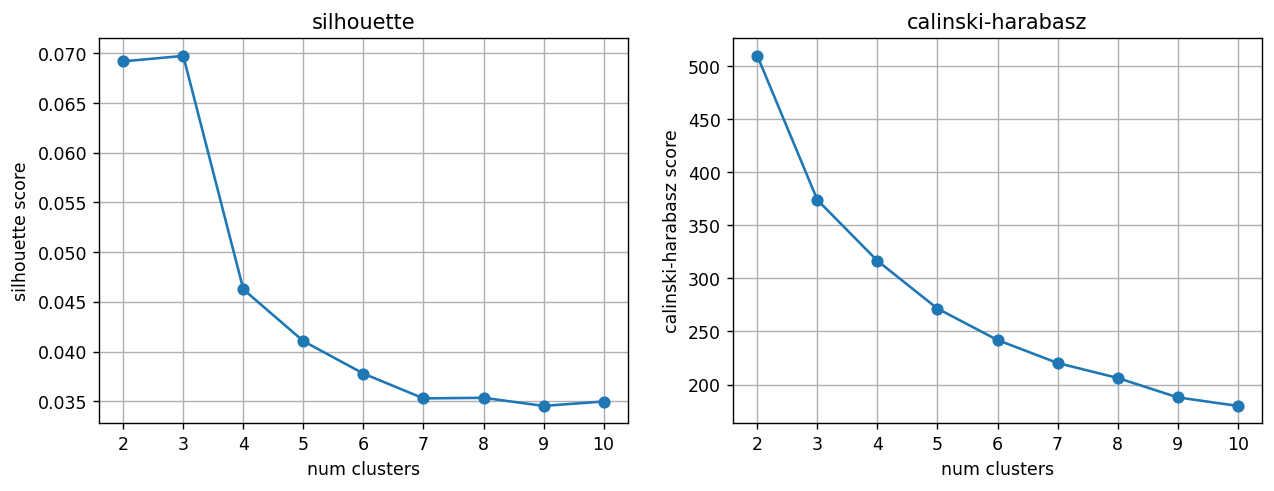

In [85]:
fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(12, 4))

ax0.plot(list(resultados_silhouette.keys()), list(resultados_silhouette.values()), "o-")
ax0.grid(True)
ax0.set_title("silhouette")
ax0.set_xlabel("num clusters")
ax0.set_ylabel("silhouette score")

ax1.plot(list(resultados_calinski.keys()), list(resultados_calinski.values()), "o-")
ax1.grid(True)
ax1.set_title("calinski-harabasz")
ax1.set_xlabel("num clusters")
ax1.set_ylabel("calinski-harabasz score")

plt.show()

los dos indices bajan casi todo el tiempo conforme aumenta k, es el sesgo as pocos grupos... ; si solo se leyera el numero mas alto, siempre saldria k=2 o k=3 ya que da 0.0692 y 0.0697. de ahi en adelante baja hasta k=10, hace falta revisar las graficas silhouette-plot

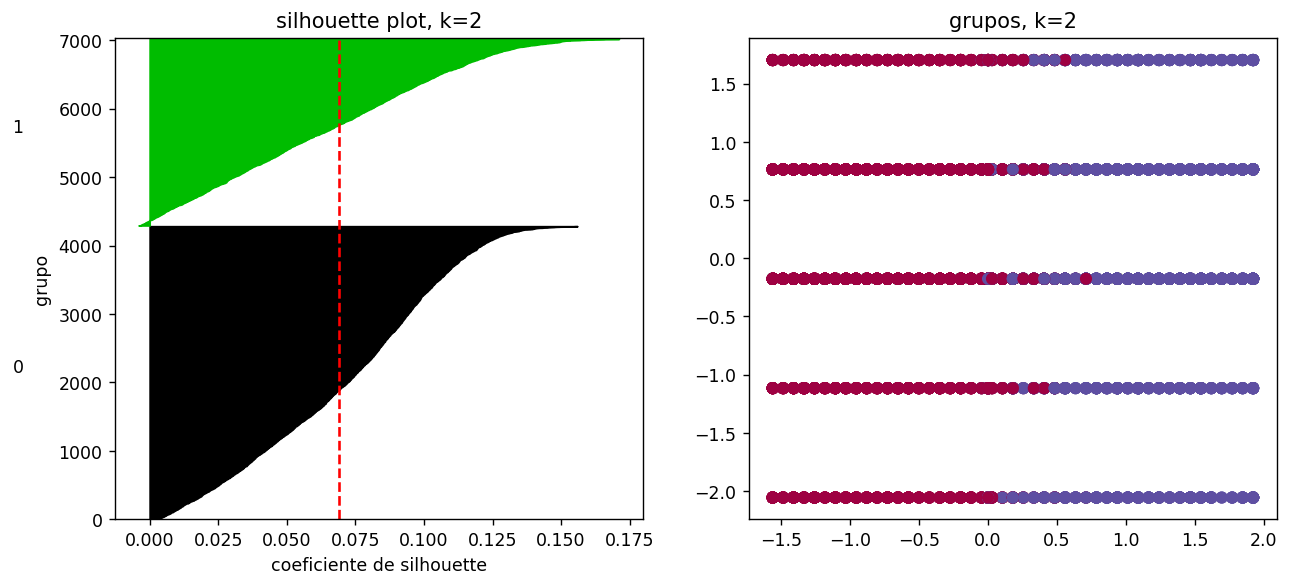

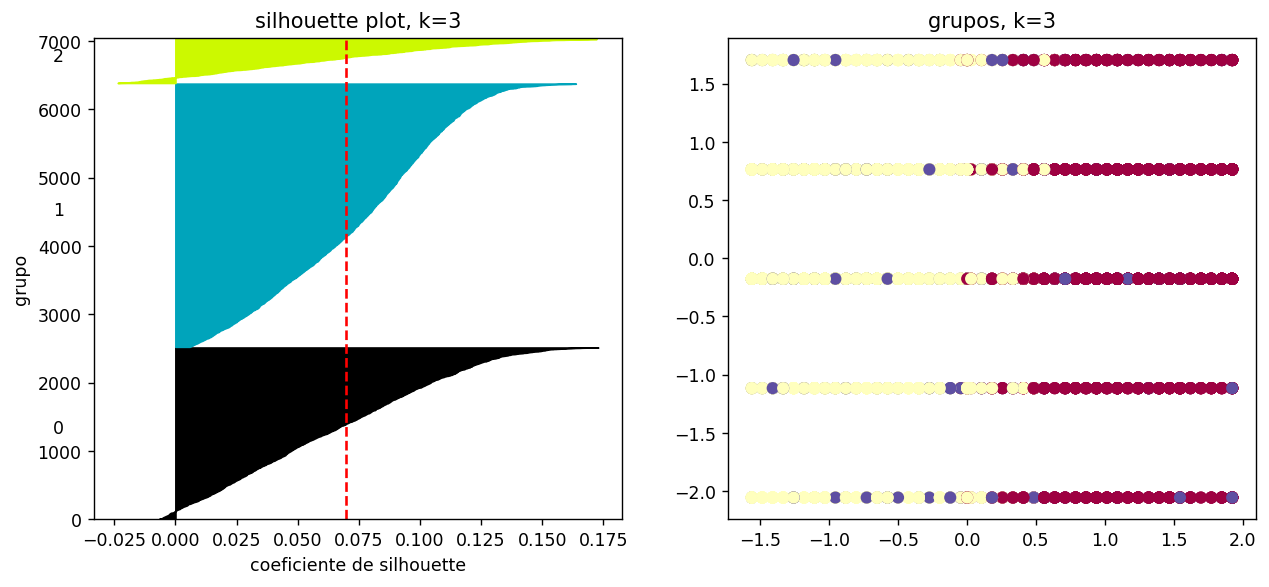

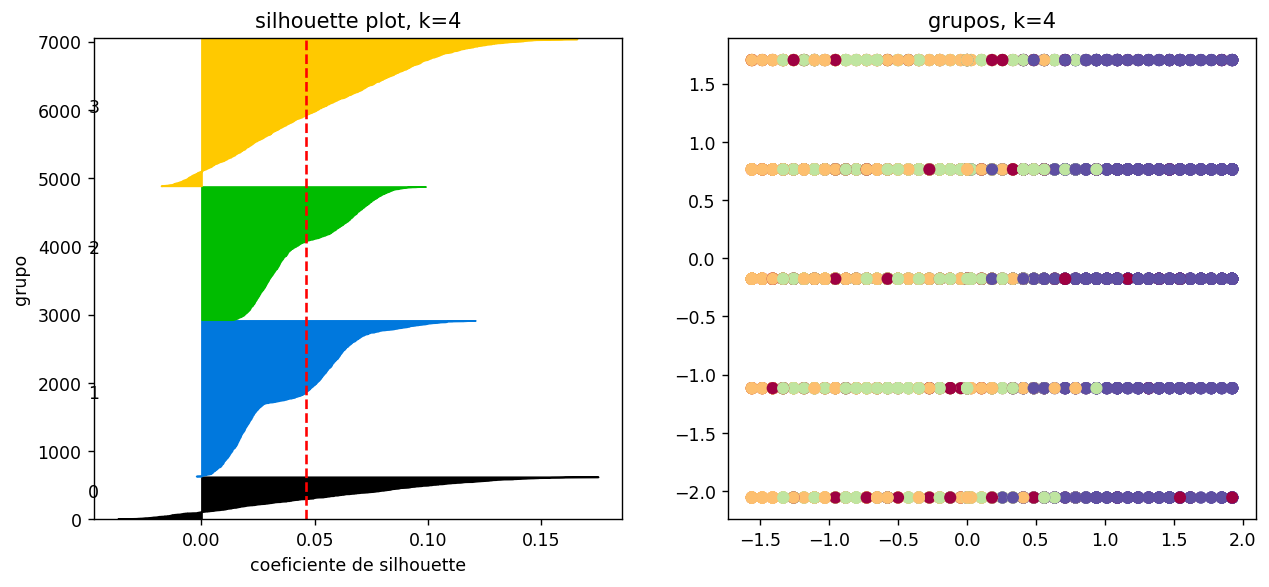

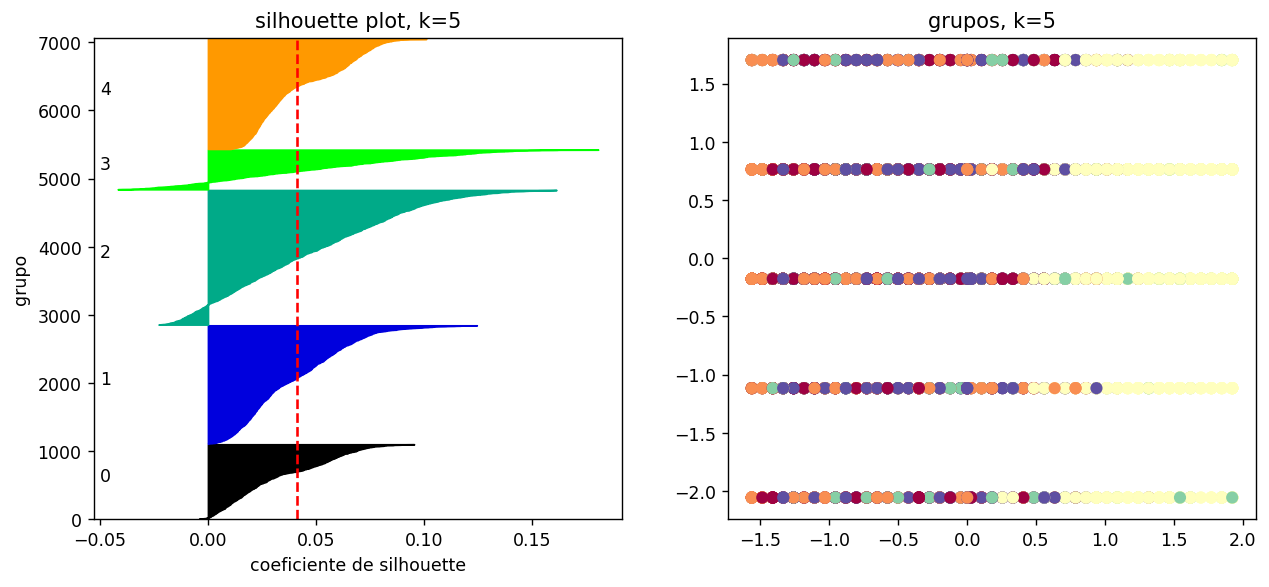

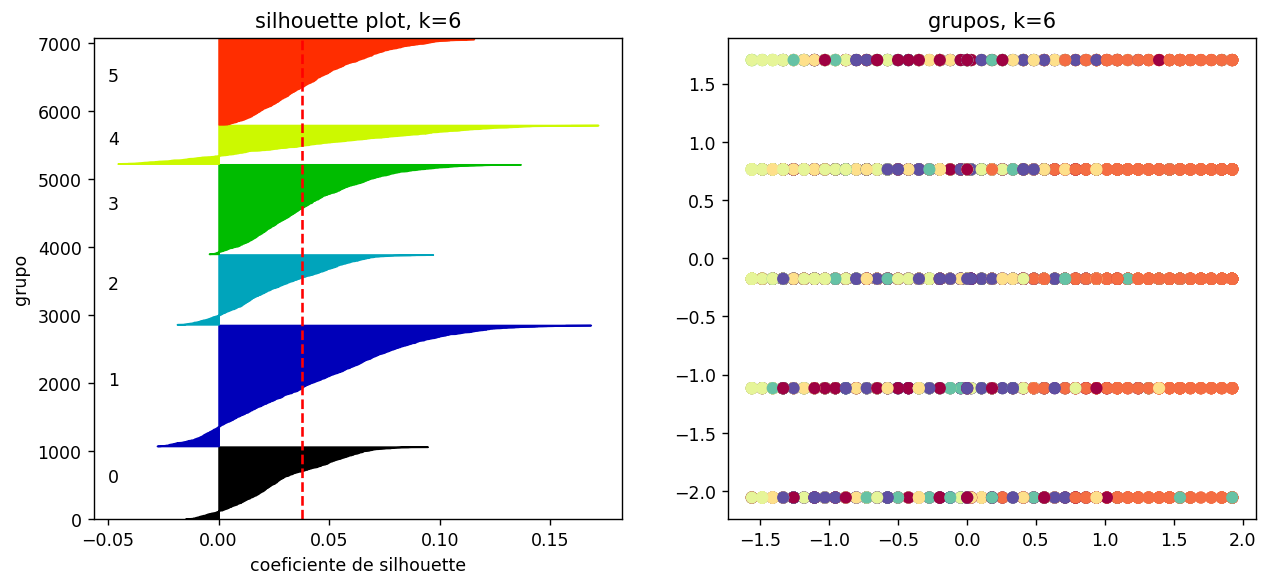

In [86]:
for k in [2, 3, 4, 5, 6]:
    fig, (ax0, ax1) = plt.subplots(1, 2)
    fig.set_size_inches(12, 5)

    """para dejar espacio en blanco separado de una grafica"""
    ax0.set_ylim([0, len(x) + (k + 1) * 10])

    y_pred = KMeans(n_clusters=k, n_init=10).fit_predict(x)
    valores_silhouette = metrics.silhouette_samples(x, y_pred)

    y_lower = 10
    for i in range(k):
        valores_i = valores_silhouette[y_pred == i]
        valores_i.sort()
        tam_i = valores_i.shape[0]
        y_upper = y_lower + tam_i
        color = cm.nipy_spectral(float(i) / k)
        ax0.fill_betweenx(np.arange(y_lower, y_upper), 0, valores_i, facecolor=color, edgecolor=color)
        ax0.text(-0.05, y_lower + 0.5 * tam_i, str(i))
        y_lower = y_upper + 10

    ax0.set_title("silhouette plot, k=" + str(k))
    ax0.set_xlabel("coeficiente de silhouette")
    ax0.set_ylabel("grupo")
    ax0.axvline(x=resultados_silhouette[k], color="red", linestyle="--")

    ax1.scatter(x[:, 0], x[:, 1], c=y_pred, cmap=plt.cm.Spectral)
    ax1.set_title("grupos, k=" + str(k))

    plt.show()

se elige k=4: con k=4 aparece un grupo compacto de 614 empleados con attrition_rate promedio de 0.69, contra ~0.14 en los otros tres. probar con k=5 no cambia nada!: ese mismo grupo de alto riesgo sigue apareciendo casi igual (588 empleados, 0.69 de promedio), no aporta nada nuevo, asi que k=4 es mas simple

In [87]:
k = 4
etiquetas = KMeans(n_clusters=k, n_init=10).fit_predict(x)
metrics.silhouette_score(x, etiquetas)

0.04626854125223285

## -----------------------  5. Segmenta el DataFrame original creando nuevos DataFrames con los empleados separados por grupo: Crea una nueva tabla resumen con los estadísticos adecuados que describa el comportamiento de las variables por grupo.

In [88]:
empleados["grupo"] = etiquetas
"""para separar por grupo1,2,3,4"""
grupos = [empleados[empleados["grupo"] == numero_grupo] for numero_grupo in range(k)]

for numero_grupo in range(k):
    print("grupo", numero_grupo, ":", len(grupos[numero_grupo]), "empleados")

"""resumen estadistico por grupo: numericas se usa el promedio, para aquellas categoricas se usa la moda"""
resumen = pd.DataFrame()
resumen["variable"] = empleados.columns[:-1]

for numero_grupo in range(k):
    fila = []
    for col in resumen["variable"]:
        if col in columnas_numericas:
            fila.append(np.round(grupos[numero_grupo][col].mean(), 2))
        else:
            fila.append(grupos[numero_grupo][col].mode()[0])
    resumen["grupo " + str(numero_grupo)] = fila

resumen

grupo 0 : 2281 empleados
grupo 1 : 2149 empleados
grupo 2 : 1956 empleados
grupo 3 : 614 empleados


,variable,grupo 0,grupo 1,grupo 2,grupo 3
0,gender,F,F,F,F
1,age,30.27,54.99,34.04,38.37
2,education_level,3.2,3.16,3.21,3.16
3,relationship_status,Married,Married,Married,Married
4,hometown,Lebanon,Lebanon,Lebanon,Lebanon
5,unit,IT,IT,IT,IT
6,decision_skill_possess,Analytical,Behavioral,Behavioral,Conceptual
7,time_of_service,6.12,25.75,8.68,12.1
8,time_since_promotion,1.38,2.4,3.47,2.41
9,growth_rate,46.84,46.73,47.53,47.57


## ----------------------- 6. interpretacion de los resultados obtenidos. a. Genera diferentes visualizaciones que ayuden a mostrar las características que tienen en común los empleados dentro de cada grupo.

In [89]:
"""barras agrupadas: promedio normalizado por variable numerica"""

resumen_num = resumen[resumen["variable"].isin(columnas_numericas)].set_index("variable")
"""para voltear filas y columnas"""
resumen_num_t = resumen_num.transpose()
resumen_num_norm = (resumen_num_t - resumen_num_t.min()) / (resumen_num_t.max() - resumen_num_t.min())

fig_barras = go.Figure()
for numero_grupo in range(k):
    fig_barras.add_trace(
        go.Bar(
            y=resumen_num_norm.loc["grupo " + str(numero_grupo)],
            x=resumen_num_norm.columns,
            name="grupo " + str(numero_grupo),
        )
    )

fig_barras.update_layout(title="promedio normalizado por variable y grupo", yaxis_title="valor normalizado")
fig_barras.show()

In [90]:

"""cajas y bigotes de attrition_rate por grupo, la variable clave que pide el reto"""

fig_cajas = go.Figure()
for numero_grupo in range(k):
    fig_cajas.add_trace(go.Box(y=grupos[numero_grupo]["attrition_rate"], name="grupo " + str(numero_grupo)))
fig_cajas.update_layout(title="attrition_rate por grupo", yaxis_title="attrition_rate", boxmode="group")
fig_cajas.show()

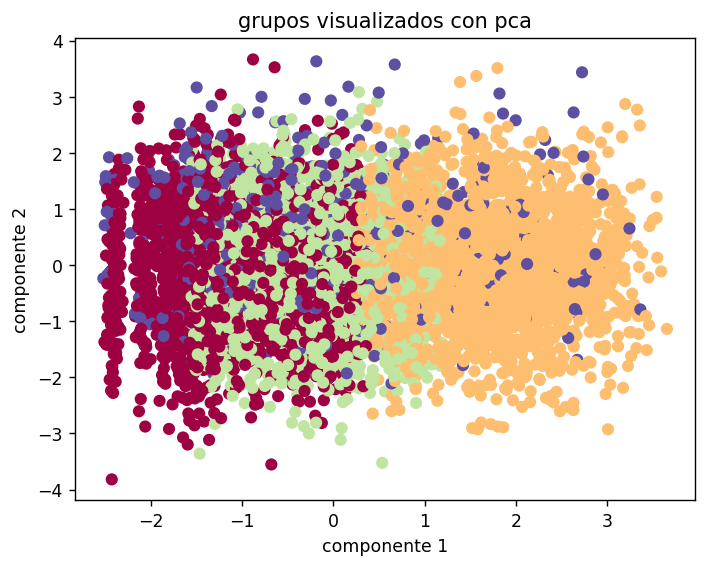

In [91]:
"""visualizacion con pca, se agrupo con las 47 variables (numericas + categoricas codificadas), pca solo se usa para poder ver los 4 grupos en dos dimensiones"""

pca = PCA(n_components=2)
x_pca = pca.fit_transform(x)

plt.scatter(x_pca[:, 0], x_pca[:, 1], c=etiquetas, cmap=plt.cm.Spectral)
plt.title("grupos visualizados con pca")
plt.xlabel("componente 1")
plt.ylabel("componente 2")
plt.show()

# ----------------------- 6. b Redacta una historia con las conclusiones más importantes del análisis de manera que ayude a la toma de decisiones.



tengo estos dataframes por cada grupo con su tamaño:
tamanos de los grupos:
1. grupo 0 = 1955,
2. grupo 1 = 2280,
3. grupo 2 = 614,
4. grupo 3 = 2151.

el hallazgo principal es el grupo 2: son 614 empleados que representa un 8.8% de la poblacion total con attrition_rate promedio de 0.69 que es bastante mas que el resto de los grupos. este grupo no se distingue por departamento, genero, estado civil, ciudad de origen ni tipo de compensacion asi que el riesgo de desercion no esta concentrado en un area de la empresa en particular

los otros tres grupos, con attrition_rate bajo y parecido entre ellos se diferencian en su plan de carrera y recorrido

- grupo 1: empleados mas nuevos con edad promedio 30, mas o menos unos 6 anios de antiguedad, poco tiempo desde su ultima promocion;
- grupo 3: empleados veteranos con edad promedio 55, mas o menos 26 anios de antiguedad;
- grupo 0: empleados de antiguedad media con mas o menos unos 9 anios pero con el tiempo mas largo desde su ultima promocion con 3.5 anios;

el estancamiento en la promocion no puede explicar la desercion en estos datos aunque esten mas tiempo sin ascender de su puesto

lo que rrhh deberia de hacer en primer lugar es buscar el riesgo en otro lado, e identificar alguna otra fuente para poder comprender el perfil del grupo 2 que es el que mas attrition_rate tiene. quizas el problema no viene con si ascenden o no, quiazs es algo mas con las variables que le siguen, en este caso yo considero que (work life balance) es la que podria analizarse aun mas.
